# Lab 4: Implementing tabular Q-learning to solve CartPole


Running in Training mode
Episode: 100 | Total Reward: 10.0 | Epsilon: 1.00 | Mean Rewards (last 100): 22.2
Episode: 200 | Total Reward: 19.0 | Epsilon: 1.00 | Mean Rewards (last 100): 22.3
Episode: 300 | Total Reward: 15.0 | Epsilon: 0.99 | Mean Rewards (last 100): 22.1
Episode: 400 | Total Reward: 19.0 | Epsilon: 0.99 | Mean Rewards (last 100): 25.0
Episode: 500 | Total Reward: 16.0 | Epsilon: 0.99 | Mean Rewards (last 100): 22.1
Episode: 600 | Total Reward: 14.0 | Epsilon: 0.99 | Mean Rewards (last 100): 22.5
Episode: 700 | Total Reward: 18.0 | Epsilon: 0.99 | Mean Rewards (last 100): 20.9
Episode: 800 | Total Reward: 15.0 | Epsilon: 0.98 | Mean Rewards (last 100): 23.0
Episode: 900 | Total Reward: 46.0 | Epsilon: 0.98 | Mean Rewards (last 100): 22.2
Episode: 1000 | Total Reward: 31.0 | Epsilon: 0.98 | Mean Rewards (last 100): 24.1
Episode: 1100 | Total Reward: 51.0 | Epsilon: 0.98 | Mean Rewards (last 100): 22.4
Episode: 1200 | Total Reward: 21.0 | Epsilon: 0.98 | Mean Rewards (las

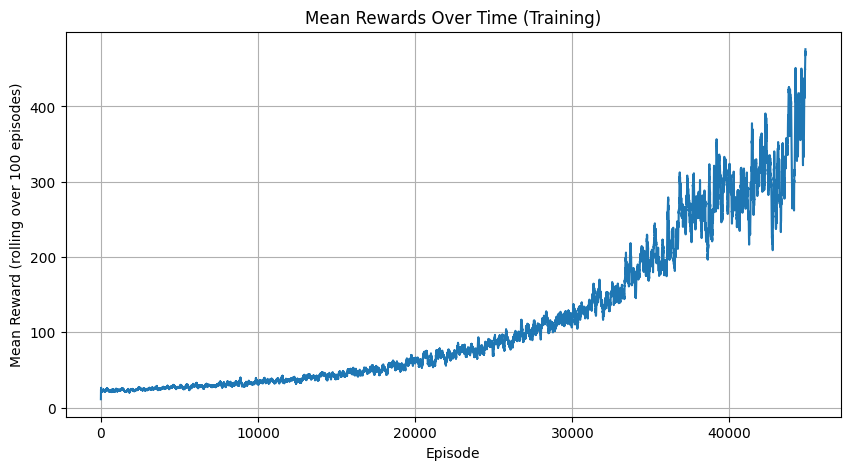

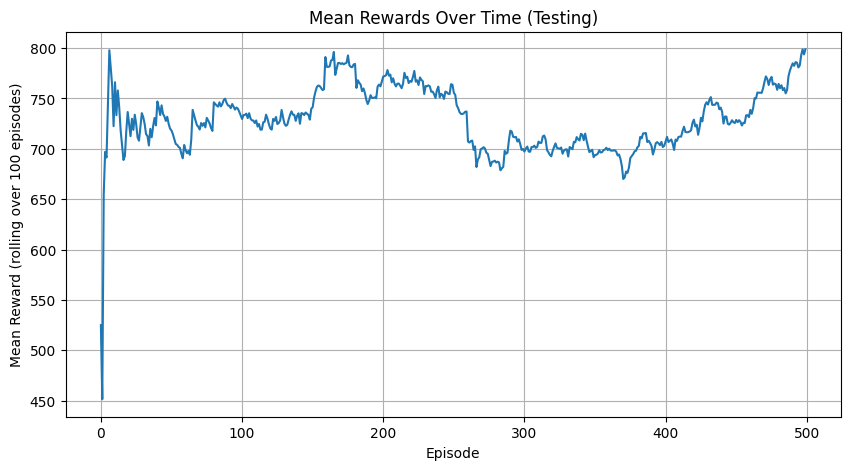

In [12]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os

def run(episodes, is_training=True, render=False):
    # Create the CartPole environment
    # The 'human' render mode displays the environment in a window
    env = gym.make('CartPole-v1', render_mode='rgb_array')

    # 1. Making continuous state space into discrete bins ==> use a finite Q-table.
    # [Cart Position, Cart Velocity, Pole Angle, Pole Angular Velocity]
    pos_space = np.linspace(-2.4, 2.4, 10)
    vel_space = np.linspace(-4, 4, 10)
    ang_space = np.linspace(-0.2095, 0.2095, 10) # 12 degrees in radians
    ang_vel_space = np.linspace(-4, 4, 10)

    # 2. Initialising Q-Table
    q_table_path = 'cartpole.pkl'
    if is_training:
        # Dimensions are: (pos_bins, vel_bins, ang_bins, ang_vel_bins, num_actions)
        # add 1 to each dimension size to accommodate values that fall outside the bins.
        q = np.zeros((len(pos_space) + 1, len(vel_space) + 1, len(ang_space) + 1, len(ang_vel_space) + 1, env.action_space.n))
    else:
        # Load the pre-trained Q-table for testing/evaluation.
        try:
            with open(q_table_path, 'rb') as f:
                q = pickle.load(f)
        except FileNotFoundError:
            print(f"Error: Could not find Q-table file '{q_table_path}'. Train the model first")
            return

    # 3. Hyperparameters
    ALPHA = 0.1
    GAMMA = 0.99
    epsilon = 1.0       # Initial exploration rate (100% random actions)
    epsilon_decay = 0.00002

    rng = np.random.default_rng() # Random number generator for exploration

    # 4. Training
    rewards_per_episode = []
    solved_threshold = 475.0 # official requirement for CartPole-v1
    mean_reward_window = 100

    print(f"\nRunning in {'Training' if is_training else 'Testing'} mode")

    for i in range(episodes):
        # Reset environment for a new episode
        state_continuous = env.reset()[0]
        
        # Digitize the continuous state into discrete bins
        state_p = np.digitize(state_continuous[0], pos_space)
        state_v = np.digitize(state_continuous[1], vel_space)
        state_a = np.digitize(state_continuous[2], ang_space)
        state_av = np.digitize(state_continuous[3], ang_vel_space)

        terminated = False
        total_rewards = 0

        while not terminated:
            # Epsilon-Greedy Action Selection
            if is_training and rng.random() < epsilon:
                # Explore: Choose a random action
                action = env.action_space.sample()
            else:
                # Exploit: Choose the best known action from the Q-table
                action = np.argmax(q[state_p, state_v, state_a, state_av, :])

            # Take the chosen action
            new_state_continuous, reward, terminated, _, _ = env.step(action)
            
            # Digitize the new state
            new_state_p = np.digitize(new_state_continuous[0], pos_space)
            new_state_v = np.digitize(new_state_continuous[1], vel_space)
            new_state_a = np.digitize(new_state_continuous[2], ang_space)
            new_state_av= np.digitize(new_state_continuous[3], ang_vel_space)

            # Q-Value Update
            if is_training:
                # Q-learning formula
                current_q = q[state_p, state_v, state_a, state_av, action]
                max_future_q = np.max(q[new_state_p, new_state_v, new_state_a, new_state_av, :])
                new_q = current_q + ALPHA * (reward + GAMMA * max_future_q - current_q)
                
                q[state_p, state_v, state_a, state_av, action] = new_q

            # Update state for the next iteration
            state_p, state_v, state_a, state_av = new_state_p, new_state_v, new_state_a, new_state_av
            total_rewards += reward

        # End of Episode
        rewards_per_episode.append(total_rewards)
        mean_rewards = np.mean(rewards_per_episode[-mean_reward_window:])

        # Decay epsilon to reduce exploration over time
        if is_training:
            epsilon = max(0, epsilon - epsilon_decay)

        # Logging and Termination Check 
        if (i + 1) % mean_reward_window == 0:
            print(f'Episode: {i+1} | Total Reward: {total_rewards:0.1f} | Epsilon: {epsilon:0.2f} | Mean Rewards (last {mean_reward_window}): {mean_rewards:0.1f}')

        if is_training and mean_rewards >= solved_threshold:
            print(f'\nSolved in {i+1} episodes')
            break

    env.close()

    # 5. Save Results
    if is_training:
        print(f'Saving Q-table to {q_table_path}')
        with open(q_table_path, 'wb') as f:
            pickle.dump(q, f)

    # Plotting the results
    mean_rewards_plot = []
    for t in range(len(rewards_per_episode)):
        mean_rewards_plot.append(np.mean(rewards_per_episode[max(0, t-mean_reward_window):(t+1)]))
    plt.figure(figsize=(10, 5))
    plt.plot(mean_rewards_plot)
    plt.title(f'Mean Rewards Over Time ({ "Training" if is_training else "Testing" })')
    plt.xlabel('Episode')
    plt.ylabel(f'Mean Reward (rolling over {mean_reward_window} episodes)')
    plt.grid(True)
    plt.savefig(f'cartpole_rewards_{"training" if is_training else "testing"}.png')

if __name__ == '__main__':
    # The agent will run for a maximum of 50,000 episodes or until it solves the environment.
    run(episodes=50000, is_training=True, render=False)

    run(episodes=500, is_training=False, render=True)
